In [81]:
import requests
from bs4 import BeautifulSoup
from datetime import datetime, date
import pandas as pd
import re
import time
import random
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import seaborn as sns
from scipy.stats import *
today = datetime.today().strftime('%Y-%m-%d')
today = '2026-06-01'
from pathlib import Path
import json
import os
JSON_CSV_DIR = os.path.join(os.getcwd(), "json_csv")
SVG = os.path.join(os.getcwd(), "svg")




In [82]:
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 16,   # title
        "axes.labelsize": 12,   # x/y labels
        "xtick.labelsize": 10,  # x ticks
        "ytick.labelsize": 10   # y ticks
    }
)

In [83]:
final_filename_sale = os.path.join(JSON_CSV_DIR,'imot_clean_sale_2026-06-06.csv')
final_filename_rent = os.path.join(JSON_CSV_DIR,'imot_clean_rent_2026-06-06.csv')


In [84]:
sale = pd.read_csv(final_filename_sale, sep=',')
rent = pd.read_csv(final_filename_rent, sep=',')

In [85]:
rent.dtypes

listing_id          str
url                 str
price           float64
district            str
square_m2       float64
n_rooms         float64
info                str
kvartal_slug        str
page              int64
dtype: object

In [86]:
sale['price'] = sale['price'].astype("Int64")
sale['n_rooms'] = sale['n_rooms'].astype("Int64")
sale['building_year'] = sale['building_year'].astype("Int64")

rent['price'] = rent['price'].astype("Int64")
rent['n_rooms'] = rent['n_rooms'].astype("Int64")

Before removing unparsed records related to properties under construction, we will check what percentage of the data would be excluded.

Перед тем, как удалять нераспарсенные данные (незавершённое строительство), проверим, какую часть (%) придётся удалить.

In [87]:
print('Data with nan, sale: ', round(len(sale[sale.isna().any(axis=1)])/len(sale)*100,2), '%')
print('Data with nan, rental: ', round(len(rent[rent.isna().any(axis=1)])/len(rent)*100,2),'%')
print(sale.isna().sum())
print(rent.isna().sum())

Data with nan, sale:  21.72 %
Data with nan, rental:  0.11 %
listing_id          1
url                 0
price              42
district            1
square_m2           1
n_rooms             1
building_year    2314
info                0
kvartal_slug        0
page                0
dtype: int64
listing_id       1
url              0
price           10
district         1
square_m2        1
n_rooms          1
info             0
kvartal_slug     0
page             0
dtype: int64


In [88]:
before = len(sale)
sale = sale.dropna(subset=['price','listing_id'])
after = len(sale)
print(f"Удалено строк_sale: {before - after}")
before = len(rent)
rent = rent.dropna(subset=['price','listing_id','district','square_m2','n_rooms'])
after = len(rent)
print(f"Удалено строк_rent: {before - after}")

Удалено строк_sale: 42
Удалено строк_rent: 10


Data cleaning. Create the `price_by_m2` column for both property sales and rentals.

Очистка данных. Создание столбца цена за квадратный метр "price_by_m2" для продажи и для аренды жилья.

In [89]:
sale['price_by_m2']=sale['price']/sale['square_m2']
rent['price_by_m2']=rent['price']/rent['square_m2']
sale.dtypes

listing_id           str
url                  str
price              Int64
district             str
square_m2        float64
n_rooms            Int64
building_year      Int64
info                 str
kvartal_slug         str
page               int64
price_by_m2      Float64
dtype: object

### Checking the Data for Normality (Histogram with KDE, Q–Q plot, skewness, and kurtosis).

### Проверка данных на нормальность распределения (гистограмма с KDE, QQ-график, коэффициент асимметрии и коэффициент эксцесса).

/tmp/ipykernel_91396/2091342885.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(


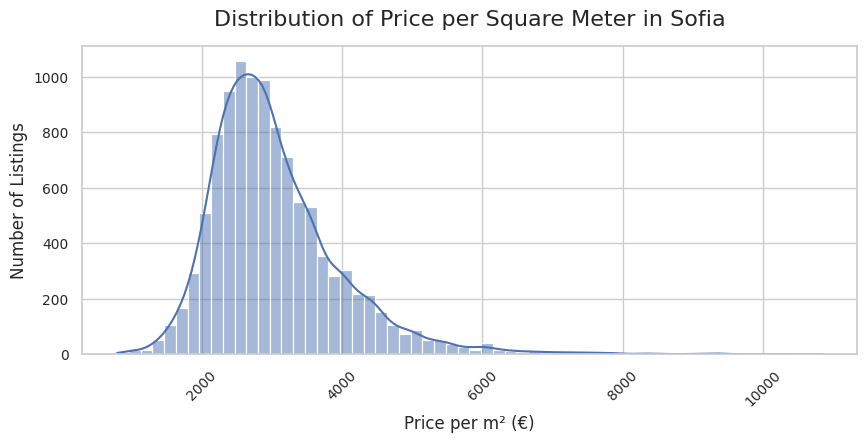

In [90]:
plt.figure(figsize=(10, 4))
fig = sns.histplot(
    data=sale,
    x="price_by_m2",
    bins=60,
    kde=True)
plt.title("Distribution of Price per Square Meter in Sofia", pad=15)
plt.xlabel("Price per m² (€)")
plt.ylabel("Number of Listings")
fig.set_xticklabels(
    fig.get_xticklabels(),
    rotation=45)

plt.savefig(os.path.join(SVG, "Distribution of Price per Square Meter in Sofia.svg"),format="svg", bbox_inches="tight")

#plt.tight_layout()
plt.show()

Although real estate prices are not expected to follow a normal distribution, the three-sigma rule was applied to reduce the influence of extreme outliers and improve the robustness of the analysis.

Хотя не предполагается, что цены на недвижимость будут подчиняться нормальному распределению, для уменьшения влияния экстремальных выбросов и повышения устойчивости анализа было применено правило трёх сигм.

In [91]:
def remove_3sigma_outliers(df, column):

    mean = df[column].mean()
    std = df[column].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    df_clean = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ].copy()

    print("Original shape:", df.shape)
    print("Cleaned shape:", df_clean.shape)

    return df_clean

sale_3sigma = remove_3sigma_outliers(sale,'price_by_m2')
rent_3sigma = remove_3sigma_outliers(rent,'price_by_m2')

Original shape: (10665, 11)
Cleaned shape: (10501, 11)
Original shape: (9353, 10)
Cleaned shape: (9217, 10)


/tmp/ipykernel_91396/1471804515.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(),rotation=45)


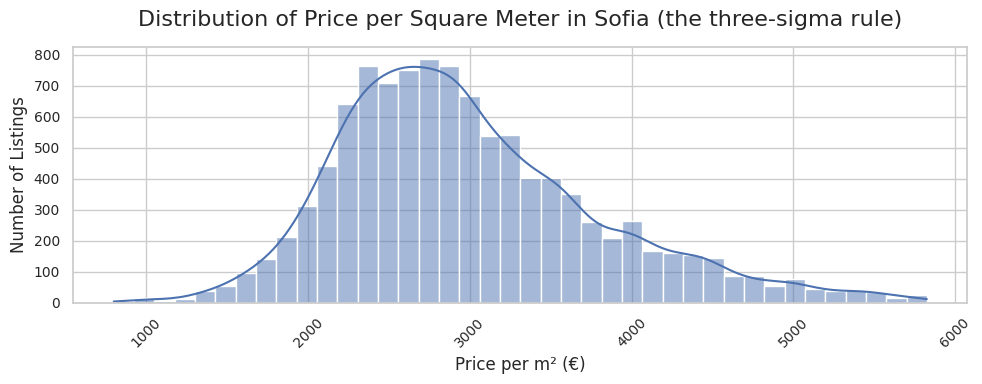

In [92]:
plt.figure(figsize=(10, 4))
fig = sns.histplot(data=sale_3sigma,x="price_by_m2",bins=40,kde=True)
plt.title("Distribution of Price per Square Meter in Sofia (the three-sigma rule)", pad=15)
plt.xlabel("Price per m² (€)")
plt.ylabel("Number of Listings")
# повернуть подписи
fig.set_xticklabels(fig.get_xticklabels(),rotation=45)
plt.tight_layout()
plt.show()

We will assess normality using visualizations and statistical tests.

Проверим данные на нормальность с помощью графиков и тестов.

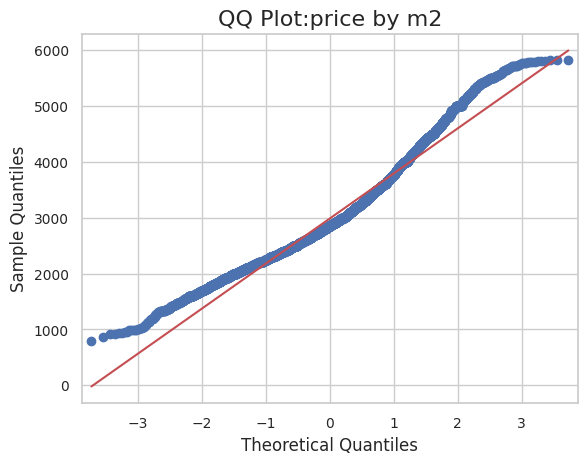

In [93]:
from statsmodels.graphics.gofplots import qqplot
qqplot(sale_3sigma['price_by_m2'], line='s') #Распределение не нормально
plt.title("QQ Plot:price by m2")
plt.show()

#### Normality Hypotheses

#### Гипотезы нормальности

In [94]:
print('SALE')
print(skewtest(sale_3sigma['price_by_m2']))
print(kurtosistest(sale_3sigma['price_by_m2']))
print(normaltest(sale_3sigma['price_by_m2']))

print('RENT')
print(skewtest(rent_3sigma['price_by_m2']))
print(kurtosistest(rent_3sigma['price_by_m2']))
print(normaltest(rent_3sigma['price_by_m2']))

SALE
SkewtestResult(statistic=np.float64(28.847824919448346), pvalue=np.float64(5.395399933662373e-183))
KurtosistestResult(statistic=np.float64(9.652863136414341), pvalue=np.float64(4.780209408715664e-22))
NormaltestResult(statistic=np.float64(925.3747693134918), pvalue=np.float64(1.1413582893683842e-201))
RENT
SkewtestResult(statistic=np.float64(23.551334517684573), pvalue=np.float64(1.2164464836500268e-122))
KurtosistestResult(statistic=np.float64(8.106280704049752), pvalue=np.float64(5.219278870146027e-16))
NormaltestResult(statistic=np.float64(620.3771444167303), pvalue=np.float64(1.935596109242695e-135))


The normality tests showed that the price-per-square-meter distributions in both the sale and rental markets differ significantly from a normal distribution (`p-value < 0.001`). Therefore, non-parametric statistical methods were used in the subsequent analysis.

Проверка на нормальность показала, что распределения цены за квадратный метр на рынках продажи и аренды статистически значимо отличаются от нормального (p-value < 0.001). Поэтому для дальнейшего анализа использовались непараметрические критерии.

### Median Price per Square Meter by Sofia District

### Медианная стоимость квадратного метра по районам Софии

We will retain only districts with at least five listings in both the sale and rental datasets.

Оставим только районы, где не меньше 5 объявлений (для объявлений о продаже и об аренде).

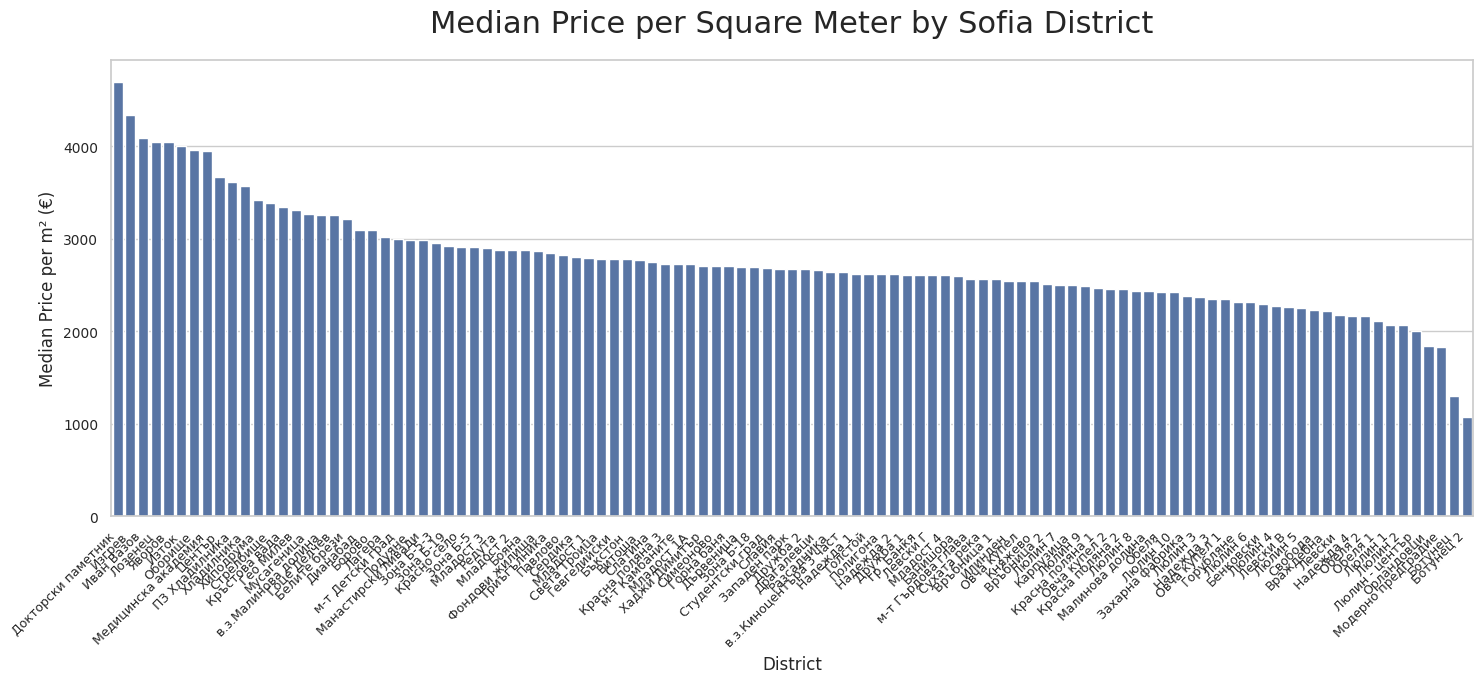

In [95]:
sale_district_count = (sale_3sigma.groupby('district')['district'].transform('size'))
sale_3sigma_cutted = sale_3sigma[sale_district_count >= 5].copy()

rental_district_count = (rent_3sigma.groupby('district')['district'].transform('size'))
rent_3sigma_cutted = rent_3sigma[rental_district_count >= 5].copy()


district_median = (sale_3sigma_cutted.groupby('district')['price_by_m2'].median().sort_values(ascending=False).reset_index())
plt.figure(figsize=(15, 7))
sns.barplot(data=district_median,x="district", y="price_by_m2")
plt.title("Median Price per Square Meter by Sofia District", pad=20,  fontsize=22)
plt.xlabel("District")
plt.ylabel("Median Price per m² (€)")
plt.xticks(rotation=45,ha='right',fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SVG, "Median Price per Square Meter by Sofia District.svg"), format="svg",bbox_inches="tight")

plt.show()

### Distribution of Listings by Construction Year

### Распределение количества объявлений по году постройки

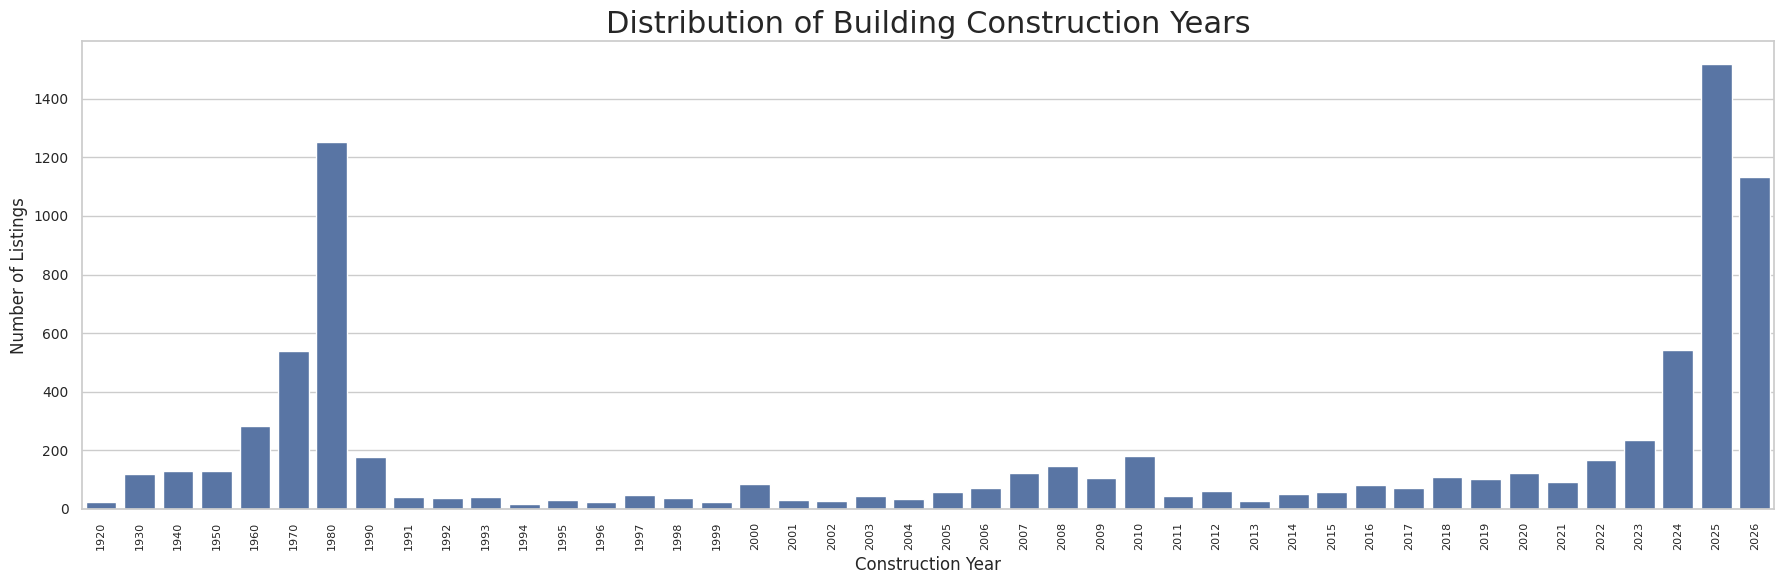

In [96]:
plt.figure(figsize=(18, 6))

sns.countplot(
    data=sale_3sigma,
    x='building_year',
)

plt.title("Distribution of Building Construction Years",  fontsize=22)
plt.xlabel("Construction Year")
plt.ylabel("Number of Listings")

plt.xticks(rotation=90, fontsize=8)
plt.savefig(os.path.join(SVG, "Distribution of Building Construction Years.svg"),format="svg",bbox_inches="tight")


plt.tight_layout()
plt.show()

Two distinct peaks in supply can be observed: properties built in the 1980s and new developments completed in 2025.

Наблюдаются два выраженных пика предложения: объекты, построенные в 1980-х годах, и новостройки 2025 года.

We will divide properties into three construction-period groups:

* **Old housing stock:** 1900–1990
* **Transitional housing stock:** 1990–2014
* **New construction:** 2014–2026

Создадим условные периоды постройки дома, старый фонд (Old stock) - 1900 - 1990, переходный переод (Transitional stock): 1990 - 2014, и новые дома (New construction): 2014-2026.

In [97]:
sale_3sigma_cutted['building_age_group'] = pd.cut( sale_3sigma_cutted['building_year'], bins=[1900, 1990, 2014, 2030], labels=['Old stock', 'Transitional stock', 'New construction' ] )

### Distribution of Properties by Construction Period

### Распределение жилья по периоду строительства

We cannot directly compare price per square meter across construction types and periods because Sofia includes both expensive and affordable districts. Therefore, prices will first be normalized against the median price of each district.

Мы не можем просто показать зависимость цены/кв_м от типа и периода строительства, так как есть дорогие районы и дешёвые районы.  Поэтому сначала сделаем нормализацию по медиане  каждого района.

In [98]:
sale_3sigma_cutted['relative_price'] = (sale_3sigma_cutted['price_by_m2']/sale_3sigma_cutted.groupby('district')['price_by_m2'].transform('median')-1)*100
rent_3sigma_cutted['relative_price'] = (rent_3sigma_cutted['price_by_m2']/rent_3sigma_cutted.groupby('district')['price_by_m2'].transform('median')-1)*100

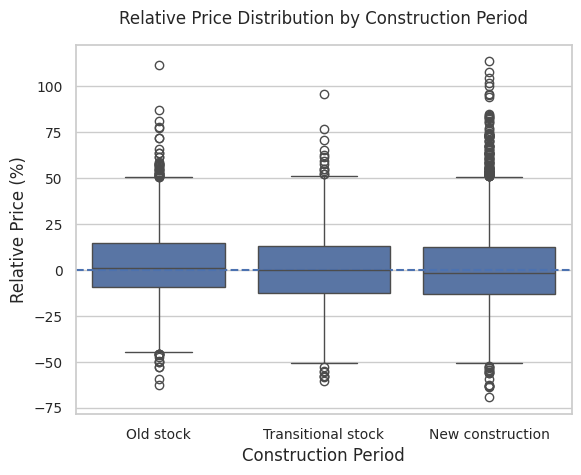

In [99]:
sns.boxplot(
    data=sale_3sigma_cutted,
    x="building_age_group",
    y="relative_price"
)


plt.title(
    "Relative Price Distribution by Construction Period",
    fontsize=12,
    pad=15
)

plt.xlabel("Construction Period")
plt.ylabel("Relative Price (%)")

plt.savefig(os.path.join(SVG, "Distribution of Properties by Construction Period.svg"),format="svg", bbox_inches="tight")

plt.axhline(0, linestyle="--")

Number of observations in each group:

Количество наблюдений в каждой выборке:

In [100]:
sale_3sigma_cutted.value_counts('building_age_group')


building_age_group
New construction      4220
Old stock             2646
Transitional stock    1376
Name: count, dtype: int64

#### Hypotheses

#### Гипотеза

*H₀: The distributions of relative price per square meter are the same across old, transitional, and new housing stock.*

*H₁: At least one construction-period group has a different distribution of relative price per square meter.*

*H_0: Распредления относительной цены за квадратный метр не различаются  в сегментах старого, переходного и нового жилого фонда.*

*H_1: По крайней мере, один тип периода постройки здания имеет различное распределение относительной цены.*

In [101]:
old_blocks = sale_3sigma_cutted.loc[sale_3sigma_cutted['building_age_group'] == 'Old stock','relative_price']
transitional_blocks = sale_3sigma_cutted.loc[sale_3sigma_cutted['building_age_group'] == 'Transitional stock','relative_price']
new_construction_blocks = sale_3sigma_cutted.loc[sale_3sigma_cutted['building_age_group'] == 'New construction','relative_price']
print(kruskal(old_blocks, transitional_blocks, new_construction_blocks))


KruskalResult(statistic=np.float64(50.44331422710583), pvalue=np.float64(1.1126882223554481e-11))


At the 0.05 significance level (`p-value = 1.11e-11`), we reject the null hypothesis. This means that the distributions of relative price differ between old, transitional, and new housing stock. We will therefore perform Dunn's multiple-comparison test.

Значит, на уровне значимости 0.05 (pvalue = 1.11e-11), мы должны отвергнуть гипотезу Н_0. То есть между группами есть различия: распредления относительной цены различаются  в сегментах старого, переходного и нового жилого фонда. Проведём тест множественного сравнения (критерий Данна).

In [102]:
import scikit_posthocs as sp
print(sp.posthoc_dunn([old_blocks, transitional_blocks, new_construction_blocks], p_adjust = 'bonferroni'))

              1         2             3
1  1.000000e+00  0.000984  3.964858e-12
2  9.837038e-04  1.000000  2.067248e-01
3  3.964858e-12  0.206725  1.000000e+00


In [103]:
for name, data in {"Old stock": old_blocks,"Transitional stock": transitional_blocks,"New construction": new_construction_blocks}.items():
    print(f"{name}: median = {data.median():.2f}")

Old stock: median = 1.02
Transitional stock: median = 0.00
New construction: median = -1.64


A statistically significant difference in relative apartment prices was found between old and transitional housing stock (`p = 0.000984`).

No statistically significant difference was found between transitional housing stock and new developments (`p = 2.067248e-01`).

A statistically significant difference in relative apartment prices was found between old housing stock and new developments (`p = 3.964858e-12`).

The median relative price is highest for old housing stock (`1.02%`), close to zero for transitional housing stock (`0.00%`), and lowest for new developments (`-1.64%`).

Между старым и переходным жилым фондом обнаружены статистически значимые различия в относительной цене квартир(p = 0.000984). 
Между переходным фондом и новостройками не выявлены статистически значимые различия (p = 2.067248e-01). 
Между старым жилым фондом и новостройками обнаружены статистически значимые различия в относительной цене квартир(p = 3.964858e-12). 

Медианная относительная цена максимальна в старом фонде ( 1.02%), в переходном фонде  близка к нулю (0.00%), в новостройках минимальна  (-1.64%).

### Comparison of Relative Prices by Number of Rooms

### Сравнение относительной цены квартир с разным количеством комнат

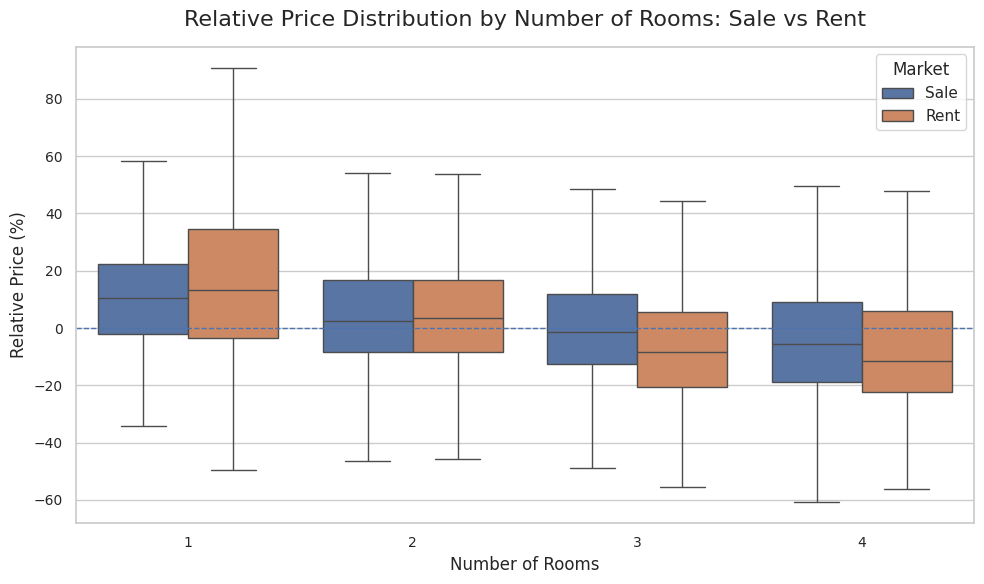

In [104]:
sale_tmp = sale_3sigma_cutted.copy()
sale_tmp["market"] = "Sale"

rent_tmp = rent_3sigma_cutted.copy()
rent_tmp["market"] = "Rent"

df_plot = pd.concat([sale_tmp, rent_tmp], ignore_index=True)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x="n_rooms",
    y="relative_price",
    hue="market",
    order=[1, 2, 3, 4],
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Relative Price Distribution by Number of Rooms: Sale vs Rent", pad=15)
plt.xlabel("Number of Rooms")
plt.ylabel("Relative Price (%)")
plt.legend(title="Market")
plt.savefig(os.path.join(SVG, "Relative Price Distribution by Number of Rooms: Sale vs Rent.svg"),format="svg", bbox_inches="tight")

plt.tight_layout()
plt.show()

*H₀: The distribution of relative price per square meter is the same for one-room, two-room, three-room, and four-room apartments.*

*H₁: At least one apartment group has a different distribution.*

*H_0: распределение относительной цены за квадратный метр одинаково для 1-, 2-, 3- и 4- комнатных квартир.*

*H_1: хотя бы одна группа отличается.*

In [105]:
from scipy.stats import kruskal
for name, type_market in [('Sale', sale_3sigma_cutted), ('rent',rent_3sigma_cutted)]:
    room1 = type_market[type_market['n_rooms'] == 1]['relative_price']
    room2 = type_market[type_market['n_rooms'] == 2]['relative_price']
    room3 = type_market[type_market['n_rooms'] == 3]['relative_price']
    room4 = type_market[type_market['n_rooms'] == 4]['relative_price']

    print(name, kruskal(room1,room2,room3, room4))
    print(sp.posthoc_dunn([room1, room2, room3, room4], p_adjust = 'bonferroni'))
    print(name,(type_market.groupby("n_rooms")["relative_price"].agg(["count", "median", "mean", "std"])
))

Sale KruskalResult(statistic=np.float64(344.4293863384092), pvalue=np.float64(2.3980303681679936e-74))
              1             2             3             4
1  1.000000e+00  4.691224e-12  4.970888e-36  4.266234e-50
2  4.691224e-12  1.000000e+00  2.830081e-26  3.284752e-38
3  4.970888e-36  2.830081e-26  1.000000e+00  1.200197e-09
4  4.266234e-50  3.284752e-38  1.200197e-09  1.000000e+00
Sale          count     median       mean        std
n_rooms                                        
1          602  10.624832  11.398045  20.999331
2         3778   2.479692   4.851776  20.113479
3         4961  -1.487688   0.533007  20.305443
4         1138   -5.70056  -3.291107  24.152438
rent KruskalResult(statistic=np.float64(875.2520288874521), pvalue=np.float64(2.065088938307745e-189))
               1              2              3             4
1   1.000000e+00   2.563498e-21  7.007506e-115  1.031695e-57
2   2.563498e-21   1.000000e+00  3.179191e-123  1.652374e-31
3  7.007506e-115  3.179191e-

One-room and two-room apartments are priced above the district median, while three-room and four-room apartments are priced below it. Three-room and four-room apartments show very similar patterns.

One-room apartments are sold at a premium relative to the typical district price, while three-room and four-room apartments are sold at a discount relative to the typical district price.

Однушки и двушки переоценены относительно районной медианы, а трёшки и четырёшки — недооценены, причём трёшки и четырёшки ведут себя практически одинаково. Однушки продаются с премией относительно типичной цены района, а трёшки и четырёшки — со скидкой относительно типичной цены района.

### Investment Attractiveness and Housing Affordability by Sofia District

### Инвестиционная привлекательность и доступность жилья по районам Софии

In addition to analyzing sale and rental prices, the project evaluates the investment attractiveness of residential property across Sofia's districts.

The following district-level metrics will be calculated:

* `sale_price_m2`: median sale price per square meter;
* `rent_price_m2`: median monthly rent per square meter;
* `yield_pct`: gross annual rental yield;
* `Payback_Period`: estimated investment payback period.

Housing affordability will also be assessed using `Months_to_buy_1m2`, which represents the number of average monthly salaries required to purchase one square meter of residential property.

The benchmark used is the average monthly salary in Sofia, estimated at EUR 1,915 according to data from Bulgaria's National Statistical Institute (NSI).

This makes it possible to compare districts from the perspective of both a potential investor and a potential homebuyer.

Помимо анализа цен продажи и аренды, интерес представляет оценка инвестиционной привлекательности недвижимости в различных районах Софии. Для этого для каждого района будут рассчитаны медианная стоимость квадратного метра на рынке продажи sale_price_m2, медианная помесячная арендная ставка за квадратный метр rent_price_m2, валовая доходность от сдачи жилья в аренду yield_pct и ориентировочный срок окупаемости инвестиций Payback_Period. 

Кроме того, будет оценена доступность жилья через количество среднемесячных зарплат, необходимых для покупки одного квадратного метра недвижимости Months_to_buy_1m2. В качестве ориентира использована средняя месячная заработная плата в Софии, составляющая 1915 евро. согласно данным Национального статистического института Болгарии (NSI).Это позволит сравнить районы с точки зрения как потенциального инвестора, так и потенциального покупателя жилья.

In [106]:
sale_district_median = sale_3sigma_cutted.groupby('district')['price_by_m2'].median()
rent_district_median = rent_3sigma_cutted.groupby('district')['price_by_m2'].median()

In [107]:
df_sale_rental = pd.concat([sale_district_median, rent_district_median],axis=1, join="inner")
df_sale_rental.columns = ['sale_price_m2','rent_price_m2']
df_sale_rental['Yield_pct']= (df_sale_rental['rent_price_m2']*12/df_sale_rental['sale_price_m2'])*100
df_sale_rental['Payback_Period_years']=100/df_sale_rental['Yield_pct']
avg_salary_in_Sofia = 1915
df_sale_rental['Months_to_buy_1m2'] = df_sale_rental['sale_price_m2']/(avg_salary_in_Sofia)
df_sale_rental.sort_values(by="Payback_Period_years",ascending=True).head(30)
#https://www.deloitte.com/cz-sk/en/Industries/real-estate/research/property-index.html?utm_source=chatgpt.com


,sale_price_m2,rent_price_m2,Yield_pct,Payback_Period_years,Months_to_buy_1m2
district,,,,,
Модерно предградие,1830.769231,11.460756,7.512092,13.311871,0.956015
Орландовци,1844.444444,10.25,6.668675,14.995483,0.963156
Левски,2176.646154,10.169492,5.606511,17.836406,1.13663
Обеля 1,2106.573872,9.142857,5.208186,19.200543,1.100039
Красна поляна 1,2468.75,10.606061,5.155351,19.397321,1.289164
Малинова долина,2430.769231,10.401389,5.134863,19.474717,1.269331
Фондови жилища,2870.545213,12.000453,5.016658,19.933589,1.498979
Люлин 2,2068.014925,8.590353,4.984695,20.061407,1.079903
Горубляне,2313.432836,9.52381,4.940092,20.242537,1.208059


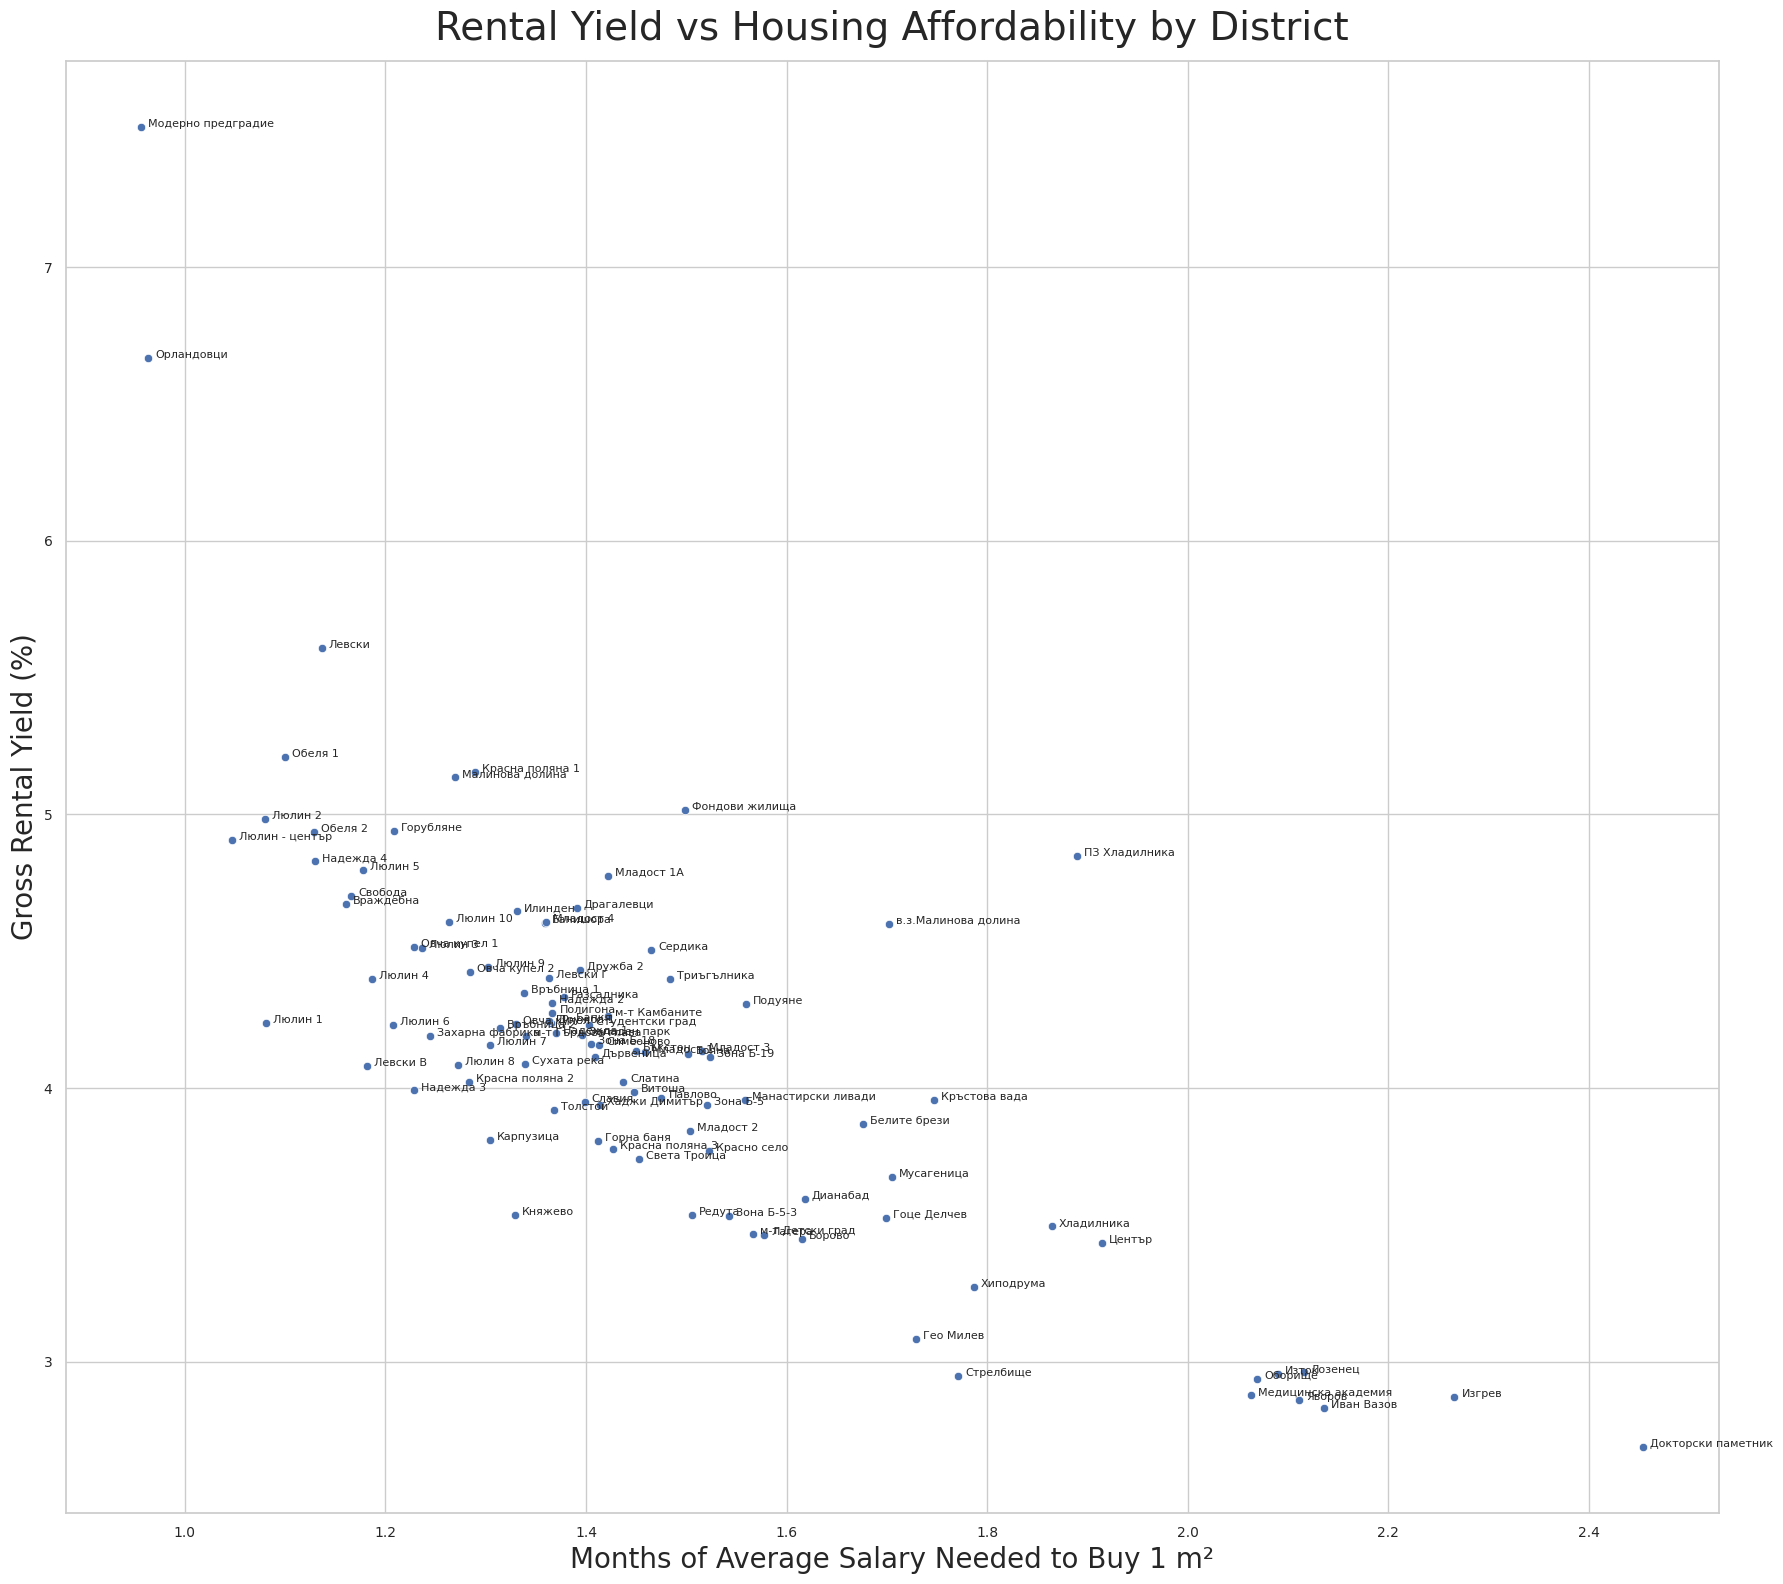

In [108]:
plt.figure(figsize=(18,16))

sns.scatterplot(
    data=df_sale_rental,
    x='Months_to_buy_1m2',
    y='Yield_pct'
)

for idx, row in df_sale_rental.iterrows():
    plt.annotate(idx,
                 (row['Months_to_buy_1m2']+0.007,
                  row['Yield_pct']),
                 fontsize=8)
    
plt.title(
    'Rental Yield vs Housing Affordability by District',
    pad=15,
    fontsize=28,
)

plt.xlabel('Months of Average Salary Needed to Buy 1 m²', fontsize=20)
plt.ylabel('Gross Rental Yield (%)', fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(SVG, "Rental Yield vs Housing Affordability by District.svg"),format="svg", bbox_inches="tight")

plt.tight_layout()
plt.show()

To compare districts simultaneously by rental yield and housing affordability, a chart will be created showing gross rental yield against the number of average monthly salaries required to purchase one square meter of property.

Districts located in the upper-left section of the chart combine relatively high rental yield with lower housing costs, making them the most attractive from an investment perspective.

By contrast, districts in the lower-right section are characterized by higher property prices and lower rental yields.

Для сравнения районов одновременно по доходности аренды и доступности жилья построен график зависимости валовой доходности аренды от количества среднемесячных заработных плат, необходимых для покупки одного квадратного метра недвижимости.

Районы, расположенные в левом верхнем углу графика, характеризуются сочетанием высокой доходности и относительно низкой стоимости жилья, что делает их наиболее привлекательными для инвестиций. Напротив, районы в правом нижнем углу отличаются высокой стоимостью недвижимости и более низкой доходностью аренды.

In [109]:
# Load district geometries / Подгружаем геометрию районов
import geopandas as gpd

map = gpd.read_file(os.path.join(JSON_CSV_DIR, "map.geojson"))
print(map.isna().sum())
map[map["name"].isna()]
map = map.dropna(subset=['name'])


osm_id                                51
name                                   4
name_bg                              118
name_en                              117
place                                 51
boundary                              51
admin_level                           51
wikidata                              51
wikipedia                             51
open_outer_rings_closed_by_script     51
open_inner_rings_closed_by_script     51
geometry                               0
dtype: int64


In [110]:
df_sale_rental_ = df_sale_rental.reset_index()
df_sale_rental_ = df_sale_rental_.merge(map[['name', 'geometry']], left_on='district', right_on='name', how='inner', indicator=True)
df_sale_rental_['_merge'].value_counts()
df_sale_rental_ = df_sale_rental_.drop(columns=['_merge', 'name'])

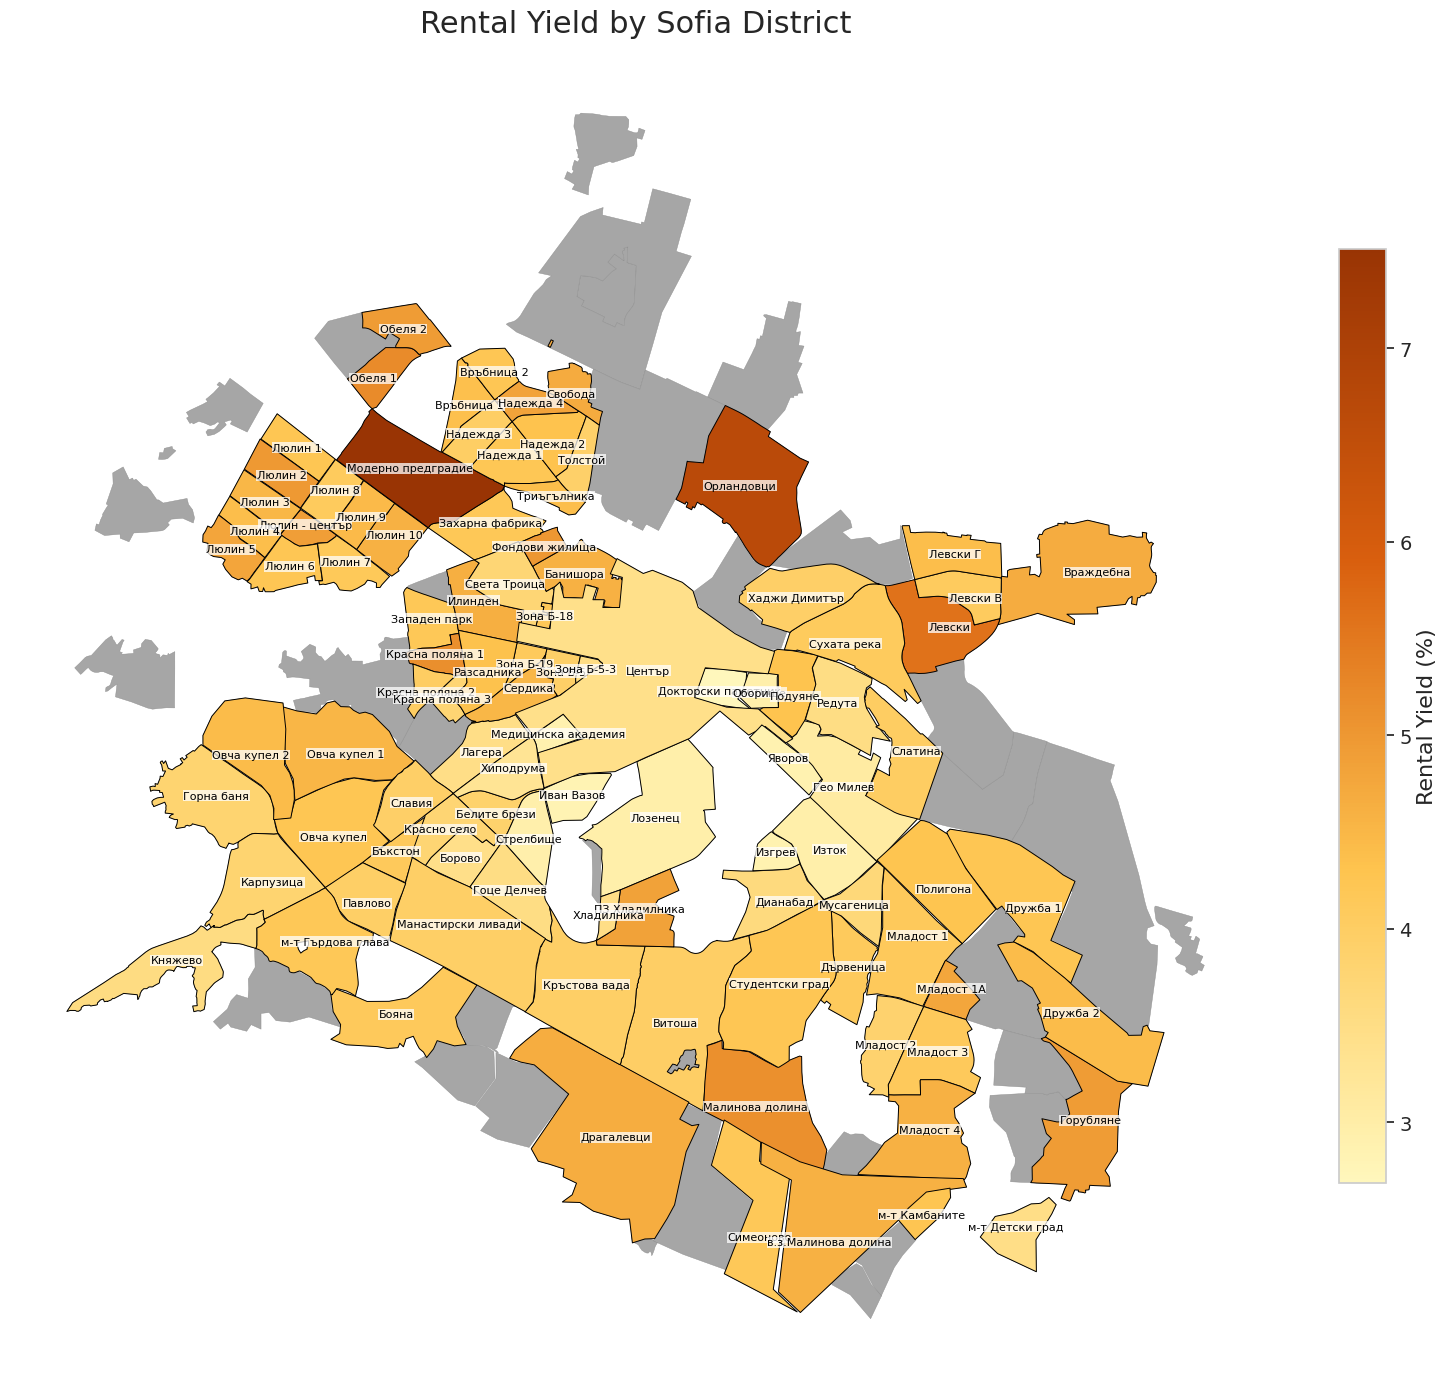

In [111]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df_sale_rental_geo = gpd.GeoDataFrame(
    df_sale_rental_,
    geometry="geometry",
    crs=map.crs
)

# Power BI style palette
cmap = LinearSegmentedColormap.from_list(
    "yield_scale",
    [
        "#fff7bc",  # light yellow
        "#fec44f",  # orange
        "#d95f0e",  # dark orange
        "#993404"   # brown
    ]
)

fig, ax = plt.subplots(figsize=(16, 14))

# grey background map
map.plot(
    ax=ax,
    color="#a6a6a6",
    edgecolor="#8c8c8c",
    linewidth=0.3
)

# districts with yield
df_sale_rental_geo.plot(
    column="Yield_pct",
    cmap=cmap,
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Rental Yield (%)",
        "shrink": 0.7
    }
)

# district labels
for _, row in df_sale_rental_geo.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["district"],
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=0.3
        )
    )

ax.set_title(
    "Rental Yield by Sofia District",
    fontsize=22,
    pad=15
)

ax.axis("off")
plt.savefig(os.path.join(SVG, "Rental Yield by Sofia Distric.svg"), format="svg", bbox_inches="tight")


legend_kwds={
    "label": "Rental Yield (%)",
    "shrink": 0.9
}

legend = ax.get_figure().axes[-1]
legend.tick_params(labelsize=14)
legend.set_ylabel("Rental Yield (%)", fontsize=16)
plt.tight_layout()
plt.show()

Gross rental yield was calculated before management costs, taxes, and vacancy periods.

Данные валовой доходности были посчитаны без учёта расходов на управление, налогов, простоев.

#### Which Apartment Type Is the Most Profitable for Rental Investment?

#### Какую квартиру выгоднее покупать для сдачи в аренду (1-ю,2-ю,3-ю,4-ю)? 

In [112]:
sale_grouped = (
    sale
    .groupby(["district", "n_rooms"])
    .agg(
        sale_price=("price", "median"),
        sale_m2=("price_by_m2", "median")
    )
    .reset_index()
)
rent_grouped = (
    rent
    .groupby(["district", "n_rooms"])
    .agg(
        rent_price=("price", "median"),
        rent_m2=("price_by_m2", "median")
    )
    .reset_index()
)

sale_rent_grouped = sale_grouped.merge(
    rent_grouped,
    on=["district", "n_rooms"],
    how="inner"
)

sale_rent_grouped["yield_pct"] = (sale_rent_grouped["rent_price"] * 12/sale_rent_grouped["sale_price"]* 100)

In [113]:
print(sale_rent_grouped.groupby("n_rooms")["yield_pct"].median())

n_rooms
1       4.176
2    4.019466
3    3.456389
4    3.406841
Name: yield_pct, dtype: Float64


One-room apartments have the highest median rental yield.

Наибольшую медианную доходность дают однокомнатные квартиры.

In [114]:
from scipy.stats import kruskal

yield_1 = sale_rent_grouped.loc[sale_rent_grouped["n_rooms"] == 1, "yield_pct"]
yield_2 = sale_rent_grouped.loc[sale_rent_grouped["n_rooms"] == 2, "yield_pct"]
yield_3 = sale_rent_grouped.loc[sale_rent_grouped["n_rooms"] == 3, "yield_pct"]
yield_4 = sale_rent_grouped.loc[sale_rent_grouped["n_rooms"] == 4, "yield_pct"]

result = kruskal(
    yield_1,
    yield_2,
    yield_3,
    yield_4
)

print(result)

import scikit_posthocs as sp

print(sp.posthoc_dunn( sale_rent_grouped, val_col="yield_pct", group_col="n_rooms",  p_adjust="bonferroni"))

KruskalResult(statistic=np.float64(54.484263772500256), pvalue=np.float64(8.845662663185257e-12))
              1         2             3             4
1  1.000000e+00  0.317555  1.681449e-08  3.694760e-08
2  3.175553e-01  1.000000  1.020912e-04  7.841840e-05
3  1.681449e-08  0.000102  1.000000e+00  1.000000e+00
4  3.694760e-08  0.000078  1.000000e+00  1.000000e+00


One-room and two-room apartments show comparable rental yields and form the most attractive investment group. Three-room and four-room apartments also have similar yields to each other, but underperform smaller apartments.

Однокомнатные и двухкомнатные квартиры демонстрируют сопоставимую доходность и формируют группу наиболее привлекательных объектов для инвестиций. Трёхкомнатные и четырёхкомнатные квартиры также не различаются между собой по доходности, однако уступают по этому показателю меньшим квартирам.

#### Mortgage Self-Sufficiency Assessment

#### Оценка самоокупаемости квартир при ипотечном финансировании

Based on the median sale and rental prices for each Sofia district, the mortgage payment coverage ratio will be calculated.

This indicator shows the extent to which rental income can cover the monthly mortgage payment and helps identify districts with the strongest investment potential.

The calculations use a standardized mortgage scenario:

* loan term: 30 years;
* annual interest rate: 3%;
* down payment: 20%.

На основе медианных цен продажи и аренды для каждого района Софии будет рассчитан коэффициент покрытия ипотечного платежа арендным доходом. Это позволит определить районы с наиболее привлекательным инвестиционным потенциалом. Для расчётов рассмотрим типичный сценарий ипотечного кредитования: срок кредита — 30 лет, процентная ставка — 3% годовых, первоначальный взнос — 20%.

In [115]:
import numpy as np
import pandas as pd

def mortgage_payment(price, annual_rate=0.03, years=30, down_payment=0.20):
    """
    price: цена квартиры
    annual_rate: годовая ставка, например 0.03 = 3%
    years: срок ипотеки в годах
    down_payment: первоначальный взнос, например 0.20 = 20%
    """
    
    loan_amount = price * (1 - down_payment)
    monthly_rate = annual_rate / 12
    n_months = years * 12
    if monthly_rate == 0:
        monthly_payment = loan_amount / n_months
    else:
        monthly_payment = (loan_amount* monthly_rate*(1 + monthly_rate) ** n_months / ((1 + monthly_rate) ** n_months - 1))
    return monthly_payment

To reduce differences in the composition of listings between the sale and rental markets, a standardized apartment area was used for each apartment type.

Для устранения различий в структуре предложения на рынках продажи и аренды использовалась стандартизированная площадь квартиры для каждого типа жилья.

In [116]:
#Типичная площадь 1-,2-,3-,4-я квартиры
STANDART_AREA = (
    sale_3sigma_cutted
    .groupby("n_rooms")["square_m2"]
    .median()
    .to_dict()
)

def make_mortgage_analysis(sale_df, rent_df, n_rooms=1, annual_rate=0.03,years=30, down_payment=0.20, min_ads=5, standart_area=STANDART_AREA):
    sale_filtered = sale_df[sale_df["n_rooms"] == n_rooms].copy()
    rent_filtered = rent_df[rent_df["n_rooms"] == n_rooms].copy()
    area = standart_area[n_rooms]

    sale_grouped = (sale_filtered.groupby("district").agg(sale_price_m2=("price_by_m2", "median"), sale_ads_count=("price", "count")).reset_index())
    rent_grouped = (rent_filtered.groupby("district").agg(rent_price_m2=("price_by_m2", "median"), rent_ads_count=("price", "count")).reset_index())


    df = sale_grouped.merge(rent_grouped,on="district", how="inner")
    df = df[(df["sale_ads_count"] >= min_ads) & (df["rent_ads_count"] >= min_ads)].copy()

    df["standard_area"] = area
    df["sale_price"] = df["sale_price_m2"] * area
    df["rent_price"] = df["rent_price_m2"] * area


    df["monthly_mortgage"]=df["sale_price"].apply(lambda price:mortgage_payment(price=price,annual_rate=annual_rate,years=years,down_payment=down_payment))
    df["monthly_cashflow"] = (df["rent_price"] - df["monthly_mortgage"])
    df["coverage_score"] = (df["rent_price"] - df["monthly_mortgage"]) / df[["rent_price", "monthly_mortgage"]].max(axis=1)
    df["payback_years_without_mortgage"] = ( df["sale_price"] / (df["rent_price"] * 12))

    return df.sort_values(by="coverage_score",ascending=False)

In [117]:
n_rooms = 2
annual_rate = 0.03
years = 30
down_payment = 0.20
min_ads = 5

mortgage_map_df = make_mortgage_analysis(
    sale_df=sale_3sigma_cutted,
    rent_df=rent_3sigma_cutted,
    n_rooms=n_rooms,
    annual_rate=annual_rate,
    years=years,
    down_payment=down_payment,
    min_ads=min_ads
)

In [118]:
mortgage_map_df_geo = mortgage_map_df.reset_index()
mortgage_map_df_geo = mortgage_map_df_geo.merge(map[['name', 'geometry']], left_on='district', right_on='name', how='inner', indicator=True)
mortgage_map_df_geo = mortgage_map_df_geo.drop(columns=['_merge', 'name'])
type(mortgage_map_df_geo)

pandas.DataFrame

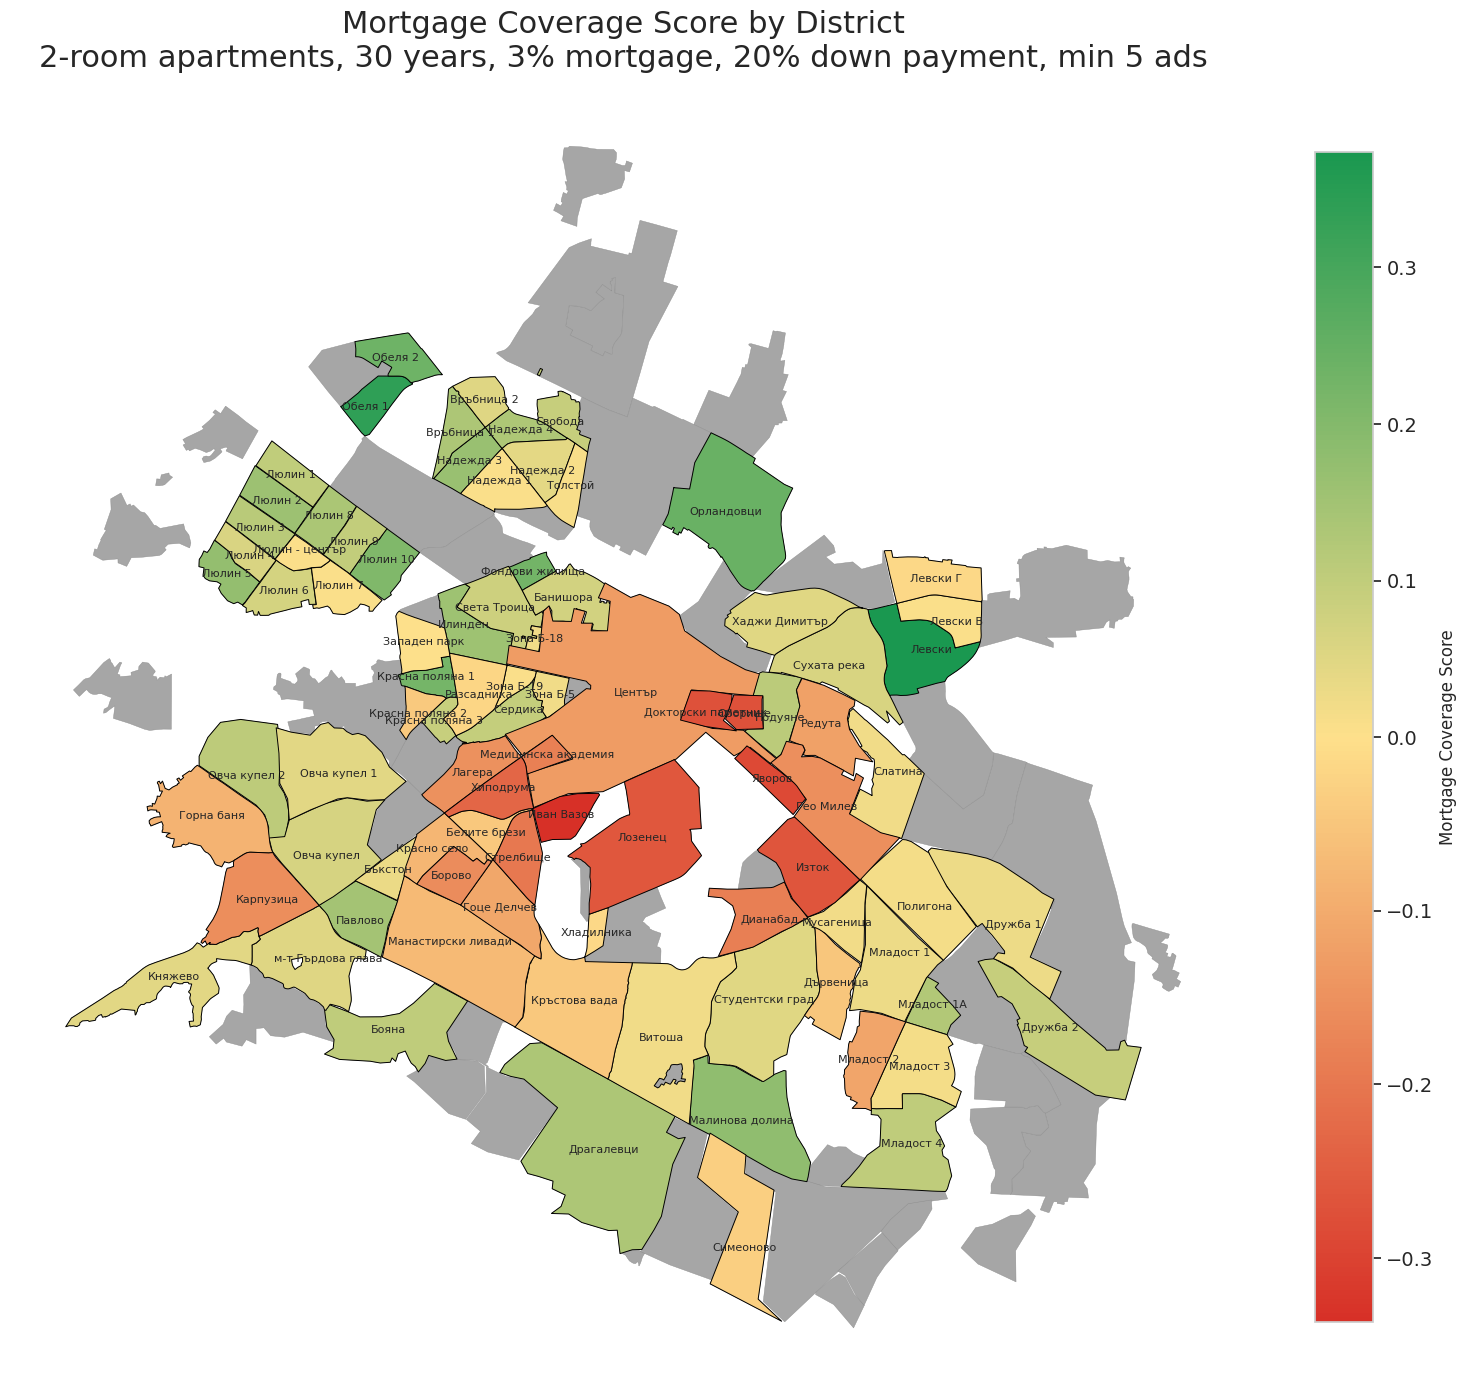

In [119]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

mortgage_map_df_geo = gpd.GeoDataFrame(
    mortgage_map_df_geo,
    geometry="geometry",
    crs=map.crs
)

# Power BI style colors
cmap = LinearSegmentedColormap.from_list(
    "coverage_red_yellow_green",
    [
        "#d73027",  # red
        "#fee08b",  # yellow (0)
        "#1a9850"   # green
    ]
)

norm = TwoSlopeNorm(
    vmin=mortgage_map_df_geo["coverage_score"].min(),
    vcenter=0,
    vmax=mortgage_map_df_geo["coverage_score"].max()
)

fig, ax = plt.subplots(figsize=(16, 14))

# grey background
map.plot(
    ax=ax,
    color="#a6a6a6",
    edgecolor="#8c8c8c",
    linewidth=0.3
)

mortgage_map_df_geo.plot(
    column="coverage_score",
    cmap=cmap,
    norm=norm,
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Mortgage Coverage Score",
        "shrink": 0.9
    }
)

# colorbar formatting
cbar_ax = ax.get_figure().axes[-1]
cbar_ax.tick_params(labelsize=14)

# district labels
for _, row in mortgage_map_df_geo.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["district"],
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    f"Mortgage Coverage Score by District\n"
    f"{n_rooms}-room apartments, "
    f"{years} years, "
    f"{annual_rate:.0%} mortgage, "
    f"{down_payment:.0%} down payment, "
    f"min {min_ads} ads",
    fontsize=22,
    pad=15
)

ax.axis("off")

plt.tight_layout()

plt.savefig(os.path.join(SVG, "Mortgage Coverage Score by District.svg"), format="svg", bbox_inches="tight")


plt.show()

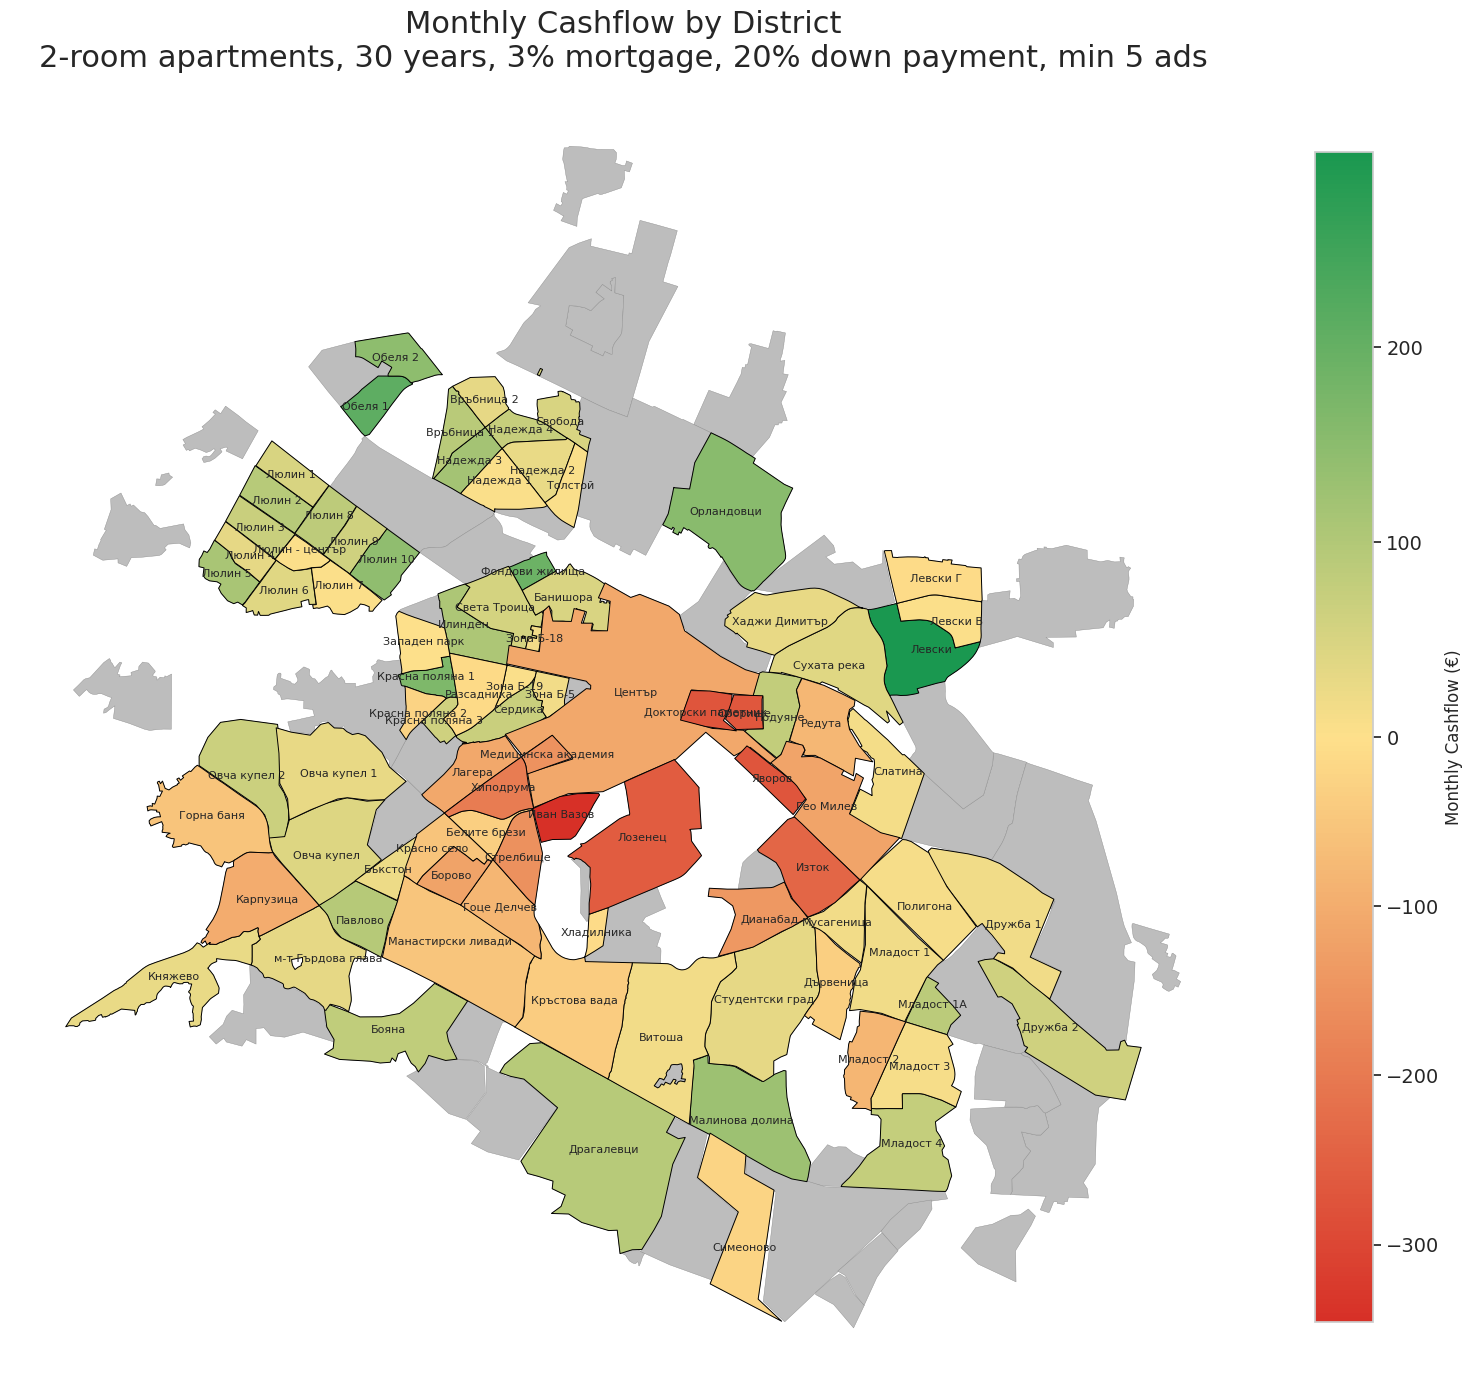

In [120]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.pyplot as plt

rooms_label = {
    1: "1-room apartments",
    2: "2-room apartments",
    3: "3-room apartments",
    4: "4-room apartments"
}

cmap = LinearSegmentedColormap.from_list(
    "cashflow_red_yellow_green",
    ["#d73027", "#fee08b", "#1a9850"]
)

norm = TwoSlopeNorm(
    vmin=mortgage_map_df_geo["monthly_cashflow"].min(),
    vcenter=0,
    vmax=mortgage_map_df_geo["monthly_cashflow"].max()
)

fig, ax = plt.subplots(figsize=(16, 14))

# grey background
map.plot(
    ax=ax,
    color="#bdbdbd",
    edgecolor="#8c8c8c",
    linewidth=0.3
)

mortgage_map_df_geo.plot(
    column="monthly_cashflow",
    cmap=cmap,
    norm=norm,
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Monthly Cashflow (€)",
        "shrink": 0.9
    }
)

# colorbar formatting
cbar_ax = ax.get_figure().axes[-1]
cbar_ax.tick_params(labelsize=14)

# district labels
for _, row in mortgage_map_df_geo.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["district"],
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    f"Monthly Cashflow by District\n"
    f"{rooms_label[n_rooms]}, "
    f"{years} years, "
    f"{annual_rate:.0%} mortgage, "
    f"{down_payment:.0%} down payment, "
    f"min {min_ads} ads",
    fontsize=22,
    pad=15
)

ax.axis("off")

plt.tight_layout()

plt.savefig(os.path.join(SVG, "Monthly Cashflow by District.svg"),format="svg", bbox_inches="tight")


plt.show()